# SOCOFing Exploratory Data Analysis

**Dataset:** Sokoto Coventry Fingerprint Dataset (SOCOFing)

### Dataset Structure
- **Real:** 6,000 fingerprint images — 600 subjects × 10 fingers (5 per hand, both hands)
- **Altered:** Same 6,000 images with three synthetic augmentation types, at three difficulty levels

### Alteration Types
- `CR` - Central Rotation: ridge pattern rotated around the core
- `Obl` - Obliteration: partial erasure of ridge detail
- `Zcut` - Z-cut: diagonal crop removing part of the fingerprint

### Difficulty Levels
`altered-easy` -> `altered-medium` -> `altered-hard` (increasing degree of distortion)

### Filename Format
Real: `{subject_id}__{gender}_{hand}_{finger}_finger.BMP`  
Altered: `{subject_id}__{gender}_{hand}_{finger}_finger_{alteration}.BMP`  
Example: `100__M_Left_index_finger.BMP`, `100__M_Left_index_finger_CR.BMP`

### Finger Label Mapping
- `index_finger` -> 0
- `little_finger` -> 1
- `middle_finger` -> 2
- `ring_finger` -> 3
- `thumb_finger` -> 4

## 1. Imports

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

In [2]:
DATA_ROOT = Path("../data")
REAL_DIR = DATA_ROOT / "real"
ALTERED_DIR = DATA_ROOT / "altered"

FINGER_LABELS = {
    "index_finger": 0,
    "little_finger": 1,
    "middle_finger": 2,
    "ring_finger": 3,
    "thumb_finger": 4,
}

ALTERATION_LABELS = {
    "CR": "Central Rotation", "Obl": "Obliteration", "Zcut": "Z-cut"
}

## 2. Loading Data

In [3]:
def parse_real_filename(filename: str) -> dict:
    """
    Parses a real fingerprint filename and extracts the subject ID, finger label, and image number.

    Args:
        filename (str): The filename to parse.
    
    Returns:
        dict: A dictionary containing the subject ID, finger label, and image number.
    """
    pattern = r"(\d+)__([MF])_(Left|Right)_(index|little|middle|ring|thumb)_finger\.BMP$"
    match = re.match(pattern, filename)
    if match:
        subject, gender, hand, finger = match.groups()
        return {
            "subject": int(subject),
            "gender": gender,
            "hand": hand,
            "finger": f"{finger}_finger",
            "label": FINGER_LABELS[f"{finger}_finger"],
            "filename": filename,
            "path": str(REAL_DIR / filename)
        }
    else:
        raise ValueError(f"Filename '{filename}' does not match the expected pattern for real fingerprints.")

In [4]:
real_samples = [parse_real_filename(f) for f in os.listdir(REAL_DIR) if f.endswith(".BMP")]
real_df = pd.DataFrame(real_samples)

In [5]:
real_df.head(10)

,subject,gender,hand,finger,label,filename,path
0,364,M,Right,little_finger,1,364__M_Right_little_finger.BMP,../data/real/364__M_Right_little_finger.BMP
1,292,M,Left,little_finger,1,292__M_Left_little_finger.BMP,../data/real/292__M_Left_little_finger.BMP
2,53,M,Left,thumb_finger,4,53__M_Left_thumb_finger.BMP,../data/real/53__M_Left_thumb_finger.BMP
3,225,M,Left,little_finger,1,225__M_Left_little_finger.BMP,../data/real/225__M_Left_little_finger.BMP
4,277,M,Right,middle_finger,2,277__M_Right_middle_finger.BMP,../data/real/277__M_Right_middle_finger.BMP
5,97,M,Right,little_finger,1,97__M_Right_little_finger.BMP,../data/real/97__M_Right_little_finger.BMP
6,503,M,Right,ring_finger,3,503__M_Right_ring_finger.BMP,../data/real/503__M_Right_ring_finger.BMP
7,426,M,Right,thumb_finger,4,426__M_Right_thumb_finger.BMP,../data/real/426__M_Right_thumb_finger.BMP
8,569,M,Left,ring_finger,3,569__M_Left_ring_finger.BMP,../data/real/569__M_Left_ring_finger.BMP
9,495,M,Right,index_finger,0,495__M_Right_index_finger.BMP,../data/real/495__M_Right_index_finger.BMP


In [ ]:
def parse_altered_filename(filename: str, difficulty: str) -> dict:
    pattern = r"(\d+)__([MF])_(Left|Right)_(index|little|middle|ring|thumb)_finger_(CR|Obl|Zcut)\.BMP$"
    match = re.match(pattern, filename)
    if match:
        subject, gender, hand, finger, alteration = match.groups()
        return {
            "subject": int(subject),
            "gender": gender,
            "hand": hand,
            "finger": f"{finger}_finger",
            "label": FINGER_LABELS[f"{finger}_finger"],
            "alteration": alteration,
            "difficulty": difficulty,
            "filename": filename,
            "path": str(ALTERED_DIR / difficulty / filename)
        }
    else:
        raise ValueError(f"Filename '{filename}' does not match the expected pattern for altered fingerprints.")

In [7]:
altered_records = [parse_altered_filename(f, difficulty) for difficulty in ["altered-easy", "altered-medium", "altered-hard"] for f in os.listdir(ALTERED_DIR / difficulty) if f.endswith(".BMP")]
altered_df = pd.DataFrame(altered_records)

In [8]:
altered_df.head(10)

,subject,gender,hand,finger,alteration,difficulty,filename,path
0,247,M,Left,index_finger,Obl,altered-easy,247__M_Left_index_finger_Obl.BMP,../data/altered/altered-easy/247__M_Left_index...
1,242,M,Left,little_finger,Zcut,altered-easy,242__M_Left_little_finger_Zcut.BMP,../data/altered/altered-easy/242__M_Left_littl...
2,128,M,Left,middle_finger,CR,altered-easy,128__M_Left_middle_finger_CR.BMP,../data/altered/altered-easy/128__M_Left_middl...
3,202,M,Left,index_finger,CR,altered-easy,202__M_Left_index_finger_CR.BMP,../data/altered/altered-easy/202__M_Left_index...
4,465,F,Right,index_finger,CR,altered-easy,465__F_Right_index_finger_CR.BMP,../data/altered/altered-easy/465__F_Right_inde...
5,400,M,Left,little_finger,Obl,altered-easy,400__M_Left_little_finger_Obl.BMP,../data/altered/altered-easy/400__M_Left_littl...
6,545,M,Right,ring_finger,CR,altered-easy,545__M_Right_ring_finger_CR.BMP,../data/altered/altered-easy/545__M_Right_ring...
7,441,M,Left,little_finger,CR,altered-easy,441__M_Left_little_finger_CR.BMP,../data/altered/altered-easy/441__M_Left_littl...
8,357,M,Right,middle_finger,Zcut,altered-easy,357__M_Right_middle_finger_Zcut.BMP,../data/altered/altered-easy/357__M_Right_midd...
9,584,M,Right,middle_finger,Zcut,altered-easy,584__M_Right_middle_finger_Zcut.BMP,../data/altered/altered-easy/584__M_Right_midd...


## 3. Dataset Statistics

In [13]:
print(real_df[["gender", "hand", "finger", "label"]].describe(include="all").T.to_string()+"\n")
print(f"Gender Distribution:\n{real_df['gender'].value_counts().rename({'M': 'Male', 'F': 'Female'}).to_string()}\n")
print(f"Hand Distribution:\n{real_df['hand'].value_counts().to_string()}\n")
print(f"Finger Distribution:\n{real_df['finger'].value_counts().sort_index().to_string()}\n")

         count unique            top  freq mean       std  min  25%  50%  75%  max
gender    6000      2              M  4770  NaN       NaN  NaN  NaN  NaN  NaN  NaN
hand      6000      2          Right  3000  NaN       NaN  NaN  NaN  NaN  NaN  NaN
finger    6000      5  little_finger  1200  NaN       NaN  NaN  NaN  NaN  NaN  NaN
label   6000.0    NaN            NaN   NaN  2.0  1.414331  0.0  1.0  2.0  3.0  4.0

Gender Distribution:
gender
Male      4770
Female    1230

Hand Distribution:
hand
Right    3000
Left     3000

Finger Distribution:
finger
index_finger     1200
little_finger    1200
middle_finger    1200
ring_finger      1200
thumb_finger     1200



In [14]:
print(altered_df[["gender", "hand", "finger", "alteration", "difficulty"]].describe(include="all").T.to_string()+"\n")
print(f"Gender Distribution:\n{altered_df['gender'].value_counts().rename({'M': 'Male', 'F': 'Female'}).to_string()}\n")
print(f"Hand Distribution:\n{altered_df['hand'].value_counts().to_string()}\n")
print(f"Finger Distribution:\n{altered_df['finger'].value_counts().sort_index().to_string()}\n")
print(f"Alteration Type Distribution:\n{altered_df['alteration'].value_counts().rename(ALTERATION_LABELS).to_string()}\n")
print(f"Difficulty Distribution:\n{altered_df['difficulty'].value_counts().to_string()}\n")

            count unique           top   freq
gender      49270      2             M  39433
hand        49270      2          Left  25038
finger      49270      5  thumb_finger  10128
alteration  49270      3           Obl  17854
difficulty  49270      3  altered-easy  17931

Gender Distribution:
gender
Male      39433
Female     9837

Hand Distribution:
hand
Left     25038
Right    24232

Finger Distribution:
finger
index_finger      9676
little_finger     9731
middle_finger     9837
ring_finger       9898
thumb_finger     10128

Alteration Type Distribution:
alteration
Obliteration        17854
Central Rotation    16439
Z-cut               14977

Difficulty Distribution:
difficulty
altered-easy      17931
altered-medium    17067
altered-hard      14272



## 4. Distribution Plots

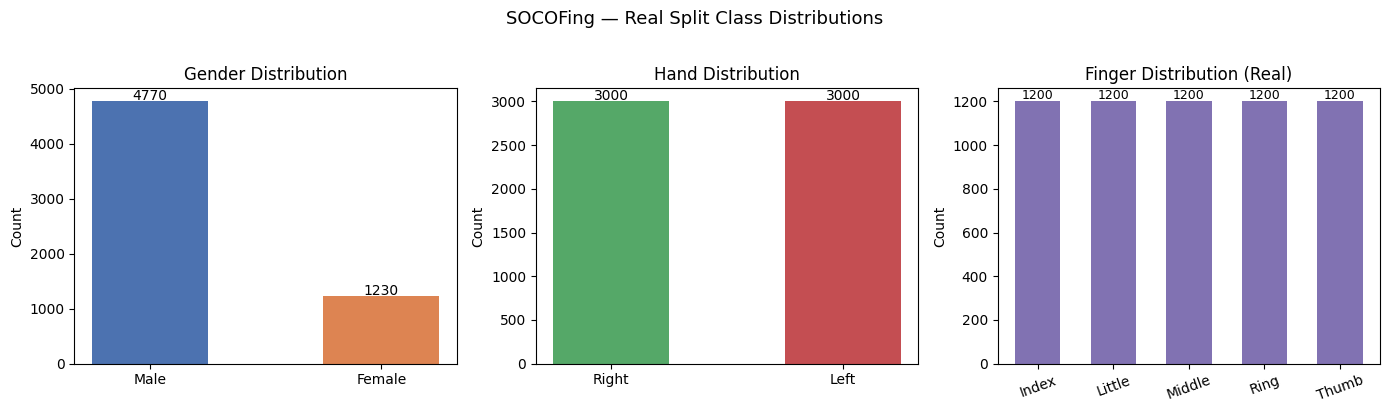

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gender
gender_counts = real_df["gender"].value_counts().rename(index={"M": "Male", "F": "Female"})
axes[0].bar(gender_counts.index, gender_counts.values, color=["#4C72B0", "#DD8452"], width=0.5)
axes[0].set_title("Gender Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# Hand
hand_counts = real_df["hand"].value_counts()
axes[1].bar(hand_counts.index, hand_counts.values, color=["#55A868", "#C44E52"], width=0.5)
axes[1].set_title("Hand Distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(hand_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontsize=10)

# Finger
finger_counts = real_df["finger"].value_counts().sort_index()
short_names = [f.replace("_finger", "").replace("_", " ").title() for f in finger_counts.index]
axes[2].bar(short_names, finger_counts.values, color="#8172B2", width=0.6)
axes[2].set_title("Finger Distribution (Real)")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=20)
for i, v in enumerate(finger_counts.values):
    axes[2].text(i, v + 10, str(v), ha="center", fontsize=9)

plt.suptitle("SOCOFing - Real Split Class Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

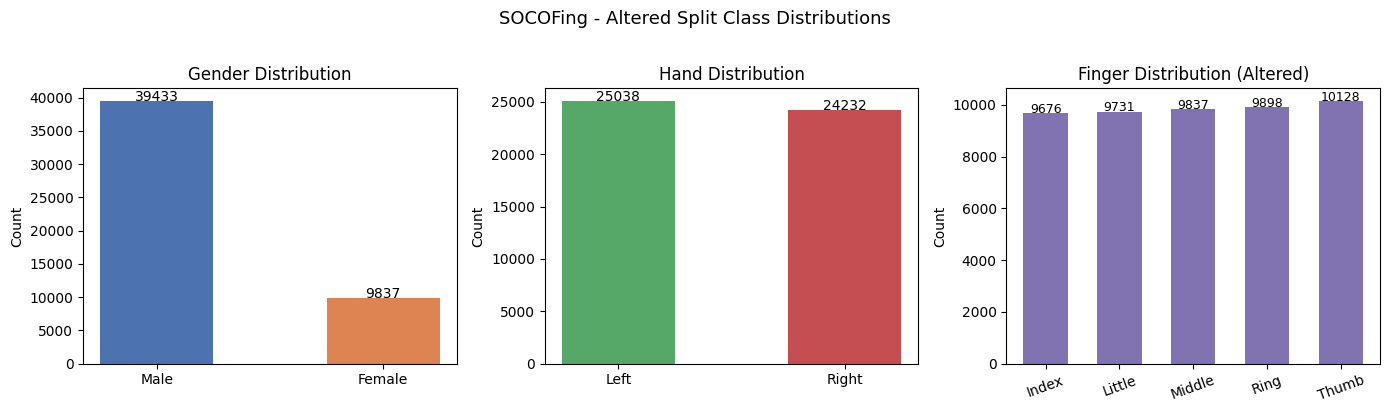

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gender
gender_counts = altered_df["gender"].value_counts().rename(index={"M": "Male", "F": "Female"})
axes[0].bar(gender_counts.index, gender_counts.values, color=["#4C72B0", "#DD8452"], width=0.5)
axes[0].set_title("Gender Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# Hand
hand_counts = altered_df["hand"].value_counts()
axes[1].bar(hand_counts.index, hand_counts.values, color=["#55A868", "#C44E52"], width=0.5)
axes[1].set_title("Hand Distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(hand_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontsize=10)

# Finger
finger_counts = altered_df["finger"].value_counts().sort_index()
short_names = [f.replace("_finger", "").replace("_", " ").title() for f in finger_counts.index]
axes[2].bar(short_names, finger_counts.values, color="#8172B2", width=0.6)
axes[2].set_title("Finger Distribution (Altered)")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=20)
for i, v in enumerate(finger_counts.values):
    axes[2].text(i, v + 10, str(v), ha="center", fontsize=9)

plt.suptitle("SOCOFing - Altered Split Class Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Sample Images (Real)

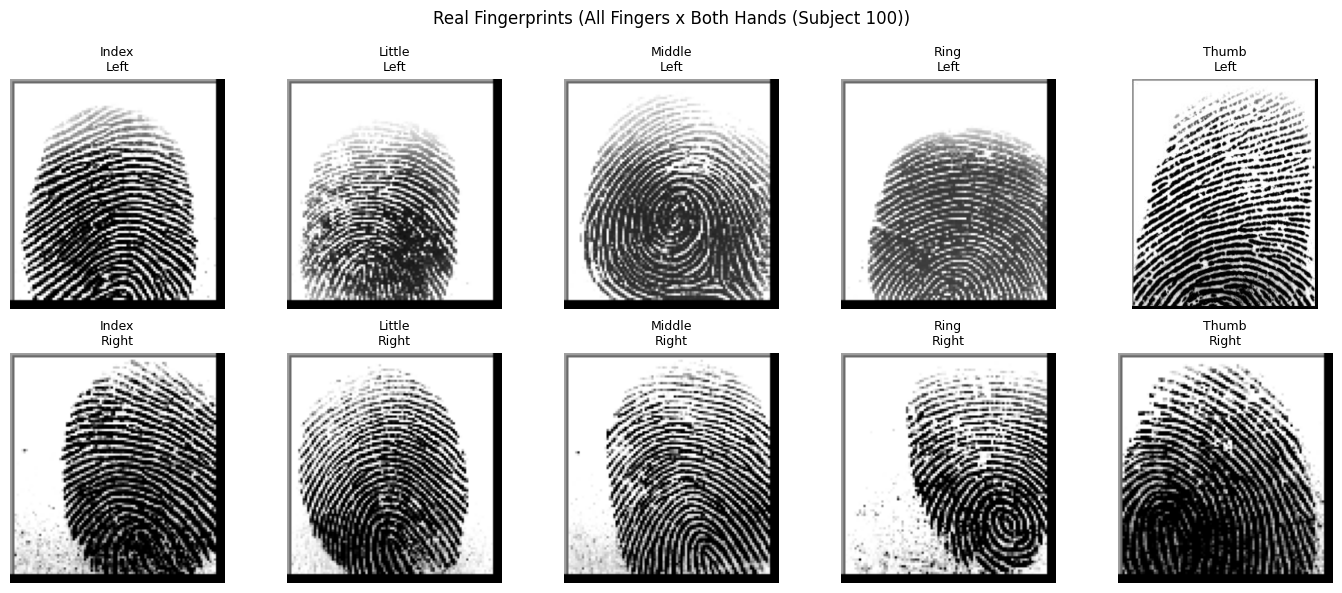

In [19]:
# One sample per finger type (first subject available for each)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for col, (finger, label) in enumerate(FINGER_LABELS.items()):
    for row, hand in enumerate(["Left", "Right"]):
        row_df = real_df[(real_df["finger"] == finger) & (real_df["hand"] == hand)]
        sample = row_df.iloc[0]
        img = Image.open(sample["path"]).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(
            f"{finger.replace('_finger','').replace('_',' ').title()}\n{hand}",
            fontsize=9
        )
        axes[row, col].axis("off")

plt.suptitle("Real Fingerprints (All Fingers x Both Hands (Subject 100))", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Sample Images (Altered)

Comparing all three alteration types (CR / Obl / Zcut) across all three difficulty levels for the same finger.

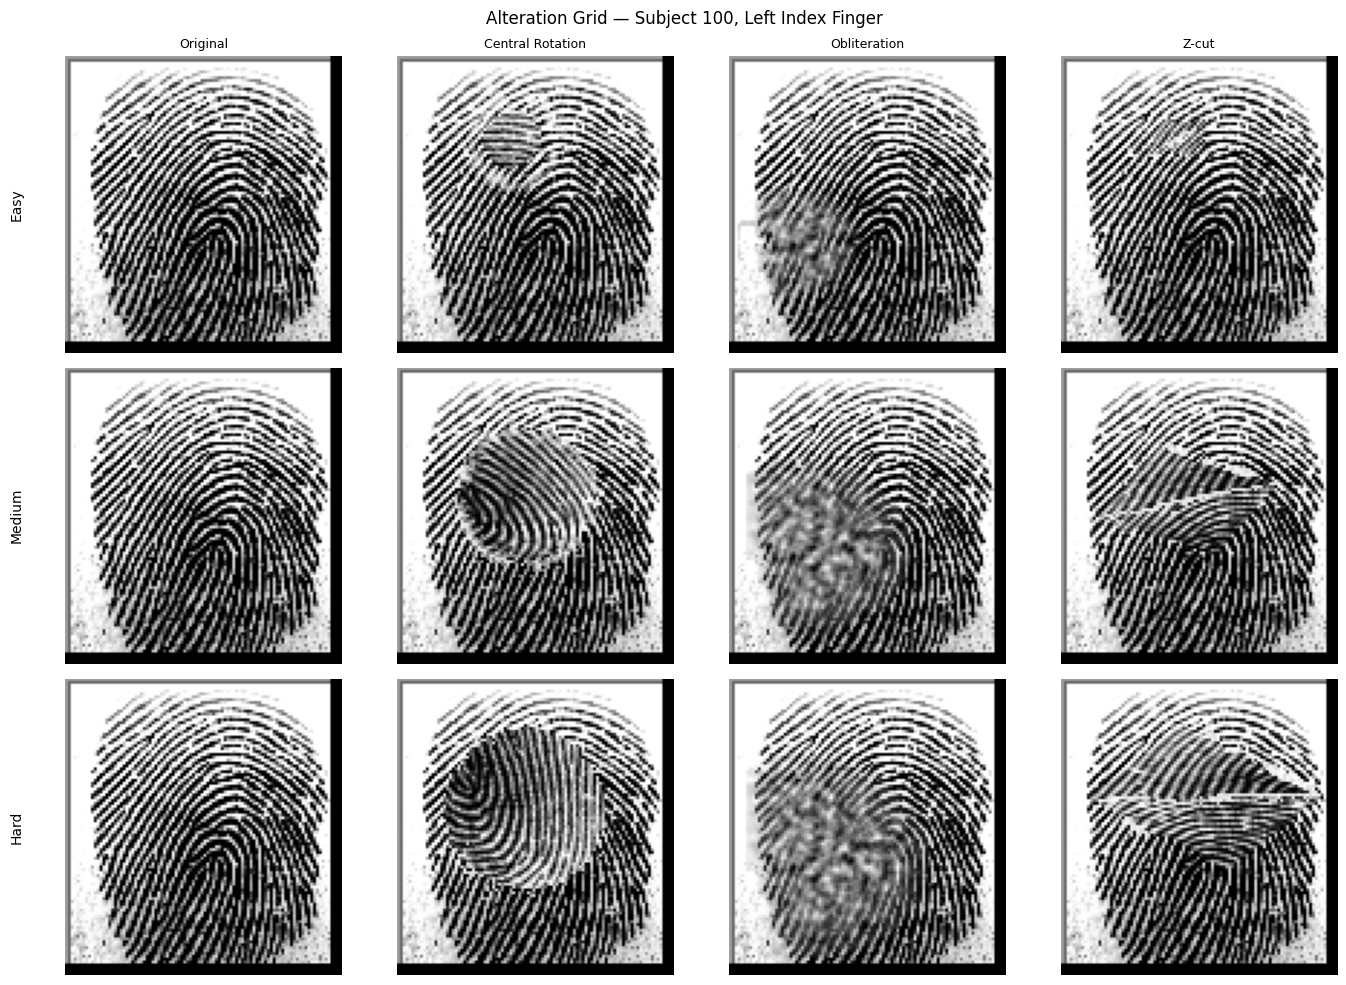

In [21]:
SUBJECT = 100
HAND = "Left"
FINGER = "index_finger"

difficulties = ["altered-easy", "altered-medium", "altered-hard"]
alt_types = ["CR", "Obl", "Zcut"]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

orig_row = real_df[
    (real_df["subject"] == SUBJECT) &
    (real_df["hand"] == HAND) &
    (real_df["finger"] == FINGER)
].iloc[0]
orig_img = Image.open(orig_row["path"]).convert("L")

for row, diff in enumerate(difficulties):
    ax = axes[row, 0]
    ax.imshow(orig_img, cmap="gray")
    ax.set_title("Original" if row == 0 else "", fontsize=9)
    ax.axis("off")
    label = diff.replace("altered-", "").capitalize()
    ax.text(-0.15, 0.5, label, transform=ax.transAxes,
            fontsize=10, va="center", ha="right", rotation=90)

for row, diff in enumerate(difficulties):
    for col, alt in enumerate(alt_types, start=1):
        row_df = altered_df[
            (altered_df["subject"] == SUBJECT) &
            (altered_df["hand"] == HAND) &
            (altered_df["finger"] == FINGER) &
            (altered_df["alteration"] == alt) &
            (altered_df["difficulty"] == diff)
        ]
        ax = axes[row, col]
        if row_df.empty:
            ax.axis("off")
            continue
        img = Image.open(row_df.iloc[0]["path"]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(ALTERATION_LABELS[alt] if row == 0 else "", fontsize=9)
        ax.axis("off")

plt.suptitle(
    f"Alteration Grid — Subject {SUBJECT}, {HAND} {FINGER.replace('_', ' ').title()}",
    fontsize=12
)
plt.tight_layout()
plt.show()

## 7. Image Properties

In [22]:
# Collect size and pixel stats from a sample of 100 real images
sample_paths = real_df["path"].sample(100, random_state=42).tolist()

sizes, means, stds = [], [], []
for p in sample_paths:
    arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
    sizes.append(arr.shape)        # (H, W)
    means.append(arr.mean())
    stds.append(arr.std())

heights = [s[0] for s in sizes]
widths = [s[1] for s in sizes]

print(f"Image dimensions: {set(sizes)} (all identical: {len(set(sizes)) == 1})")
print(f"Height: min={min(heights)}, max={max(heights)}")
print(f"Width: min={min(widths)}, max={max(widths)}")
print(f"Pixel mean: {np.mean(means):.2f} ± {np.std(means):.2f}")
print(f"Pixel std: {np.mean(stds):.2f} ± {np.std(stds):.2f}")
print(f"Pixel range: [0, 255] (uint8 grayscale)")

Image dimensions: {(298, 241), (103, 96)} (all identical: False)
Height: min=103, max=298
Width: min=96, max=241
Pixel mean: 143.83 ± 23.28
Pixel std: 103.59 ± 5.64
Pixel range: [0, 255] (uint8 grayscale)


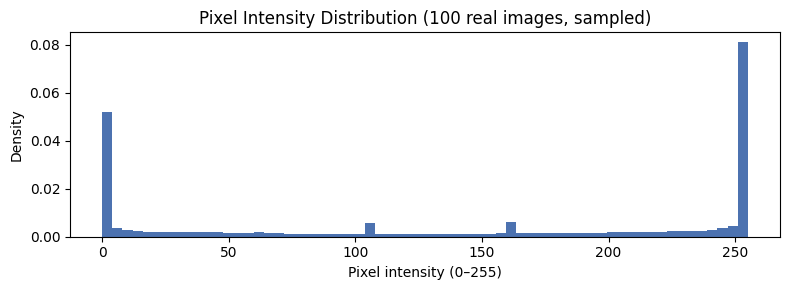

In [23]:
# Pixel intensity histogram across a sample of images
all_pixels = np.concatenate([
    np.array(Image.open(p).convert("L")).ravel()
    for p in sample_paths
])

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(all_pixels, bins=64, color="#4C72B0", edgecolor="none", density=True)
ax.set_xlabel("Pixel intensity (0–255)")
ax.set_ylabel("Density")
ax.set_title("Pixel Intensity Distribution (100 real images, sampled)")
plt.tight_layout()
plt.show()

## 8. Pair Construction for Siamese Network

The Siamese network is trained on **pairs** of images with a binary label:
- **Genuine pair (label = 0):** two images of the same finger from the same subject
- **Impostor pair (label = 1):** a real image paired with one of its altered versions

The three alteration difficulty levels provide natural curriculum control during training.

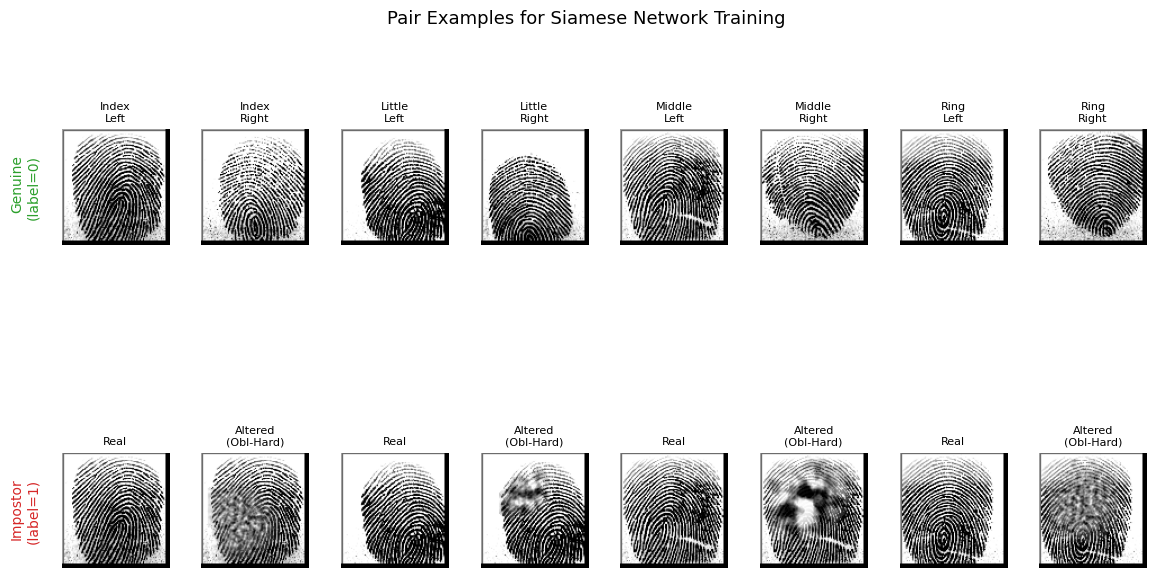

In [24]:
def load_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

subj = 100
fingers_sample = list(FINGER_LABELS.keys())[:4]

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 8, figure=fig, hspace=0.5, wspace=0.3)

for col, finger in enumerate(fingers_sample):
    lrow = real_df[(real_df["subject"] == subj) & (real_df["hand"] == "Left") & (real_df["finger"] == finger)].iloc[0]
    rrow = real_df[(real_df["subject"] == subj) & (real_df["hand"] == "Right") & (real_df["finger"] == finger)].iloc[0]
    ax_l = fig.add_subplot(gs[0, col * 2])
    ax_r = fig.add_subplot(gs[0, col * 2 + 1])
    ax_l.imshow(load_gray(lrow["path"]), cmap="gray"); ax_l.axis("off")
    ax_r.imshow(load_gray(rrow["path"]), cmap="gray"); ax_r.axis("off")
    short = finger.replace("_finger", "").replace("_", " ").title()
    ax_l.set_title(f"{short}\nLeft", fontsize=8)
    ax_r.set_title(f"{short}\nRight", fontsize=8)
    if col == 0:
        ax_l.text(-0.2, 0.5, "Genuine\n(label=0)", transform=ax_l.transAxes,
                  color="#2ca02c", fontsize=10, va="center", ha="right", rotation=90)

    alt_row = altered_df[
        (altered_df["subject"] == subj) & (altered_df["hand"] == "Left") &
        (altered_df["finger"] == finger) & (altered_df["difficulty"] == "altered-hard") &
        (altered_df["alteration"] == "Obl")
    ]
    ax_l2 = fig.add_subplot(gs[1, col * 2])
    ax_r2 = fig.add_subplot(gs[1, col * 2 + 1])
    ax_l2.imshow(load_gray(lrow["path"]), cmap="gray"); ax_l2.axis("off")
    if not alt_row.empty:
        ax_r2.imshow(load_gray(alt_row.iloc[0]["path"]), cmap="gray")
    ax_r2.axis("off")
    ax_l2.set_title("Real", fontsize=8)
    ax_r2.set_title("Altered\n(Obl-Hard)", fontsize=8)
    if col == 0:
        ax_l2.text(-0.2, 0.5, "Impostor\n(label=1)", transform=ax_l2.transAxes,
                   color="#d62728", fontsize=10, va="center", ha="right", rotation=90)

fig.suptitle("Pair Examples for Siamese Network Training", fontsize=13)
plt.show()

## 9. Theoretical Pair Counts

Estimating how many unique pairs are available for training.

In [25]:
n_subjects = real_df["subject"].nunique()
n_fingers = real_df["finger"].nunique()
n_real = len(real_df)

# Genuine pairs: same subject, same finger — choose 2 from n_hands=2 → C(2,2)=1 per (subject, finger)
genuine_pairs = n_subjects * n_fingers * 1
print(f"Genuine pairs (same subject, same finger, L vs R): {genuine_pairs:,}")

# Impostor pairs: for each real image, pair with its alteration types × difficulties
alt_per_image = altered_df.groupby(["subject", "hand", "finger"]).size()
impostor_pairs_per_image = alt_per_image.mean()
total_impostor = int(n_real * impostor_pairs_per_image)
print(f"Avg altered versions per image: {impostor_pairs_per_image:.1f}")
print(f"Impostor pairs (real vs altered): {total_impostor:,}")
print(f"Total pairs (approx): {genuine_pairs + total_impostor:,}")
print()
print(f"Imbalance ratio (impostor:genuine): {total_impostor/genuine_pairs:.1f}:1")

Genuine pairs (same subject, same finger, L vs R): 3,000
Avg altered versions per image: 8.2
Impostor pairs (real vs altered): 49,269
Total pairs (approx): 52,269

Imbalance ratio (impostor:genuine): 16.4:1
